In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
# Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', 
'23240108_203134', '23231221_101235', 
'23231221_015705', '23231220_190923', 
'23231220_122140', '23231220_053358', 
'23231220_012745', '23231219_184002', 
'23231219_110331', '23231219_034952', 
'23231218_223530', '23231218_190035', 
'23231218_152721', '23231218_093255', 
'23231218_024511', '23231217_212512', 
'23231217_171613', 
'23231217_135018', '23231216_233807', 
'23231216_211119', '23231216_194929', 
'23231216_182937', '23231216_173436', 
'23231216_145300', '23231216_100125', 
'23231216_043946', '23231216_013604'] # Ge calibration  
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [3]:
RQfiles = {'sim': np.sort(glob.glob("/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Kshell_50V_tuned_100kEvents_releaseV05-09/Processed/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root")),
           'data': [f'/scratch/perry/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_{i}.root' for i in series_list]}

In [4]:
RQdata = {'sim': None, 'data': None}
det = {'sim': 0, 'data': 1}
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = ["SeriesNumber", "EventNumber", "PTOFamps", "PTOFchisqLF", "EventTriggerID"] + [chan + "OFamps" for chan in channels] + [chan + "OFchisqLF" for chan in channels]

for datatype in list(RQdata.keys()):
    df = CDataFrame("rqDir/zip1", RQfiles[datatype], friends = [[x+":rqDir/eventTree" for x in RQfiles[datatype]]])
    if datatype=='data':
        ## Apply some basic data quality filters and get the RQs you're interested in
        logfile = '"cute_tower3testing.log"'
        df = df.Define("LEDLogFile", logfile) 
        df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
        df = df.Filter("!LEDOn")
        
    df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det[datatype]), "PTOFamps>0"])

    RQdata[datatype] = df_filtered.AsNumpy(RQs)

In [5]:
def linearize(x):
    return 1/b * (np.exp(x / a) - 1)

def pt2keV(x):
    lin_pt = linearize(x)
    recoilE = lin_pt * calibFac / LukeFac
    return recoilE

In [6]:
a, b = 2.08e-04, 1.63e+01
calibFac = 21000
LukeFac = 1 + 50 / 3
RQdata['data']['PTOFamps_keVee'] = pt2keV(RQdata['data']['PTOFamps'])
RQdata['sim']['PTOFamps_keVee'] = pt2keV(RQdata['sim']['PTOFamps']*10/4)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).


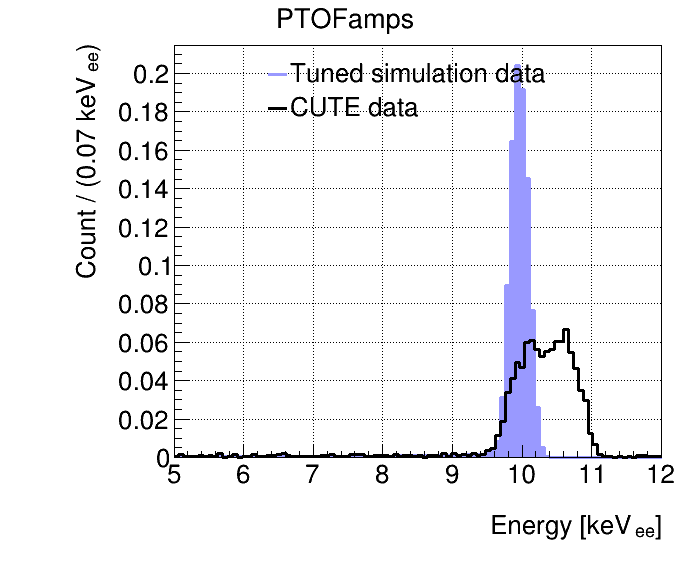

In [11]:
ROOT.gStyle.SetOptStat(0)
bins_start = 5
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", "PTOFamps;Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]" + ";Count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data1 = RQdata['sim']['PTOFamps_keVee']

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-9)
h1.SetFillColor(ROOT.kBlue-9)
h1.SetFillStyle(1001)
#h1.SetMaximum(1000)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h2", ";Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]" + ";Count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data2 = RQdata['data']['PTOFamps_keVee']

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kBlack)
    
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.38, 0.78, 0.53, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "Tuned simulation data", "l")
legend.AddEntry(h2, "CUTE data", "l")
legend.SetTextSize(0.05)

c.SetLeftMargin(0.25)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
DMCscaling = 1.0 / h1.Integral()
CUTEscaling = 1.0 / h2.Integral()
h1.Scale(DMCscaling)
h2.Scale(CUTEscaling)
h1.Draw("HIST")
h2.Draw("HIST SAME")
legend.Draw()
c.SetGrid(1,1)
#c.SetLogy()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).


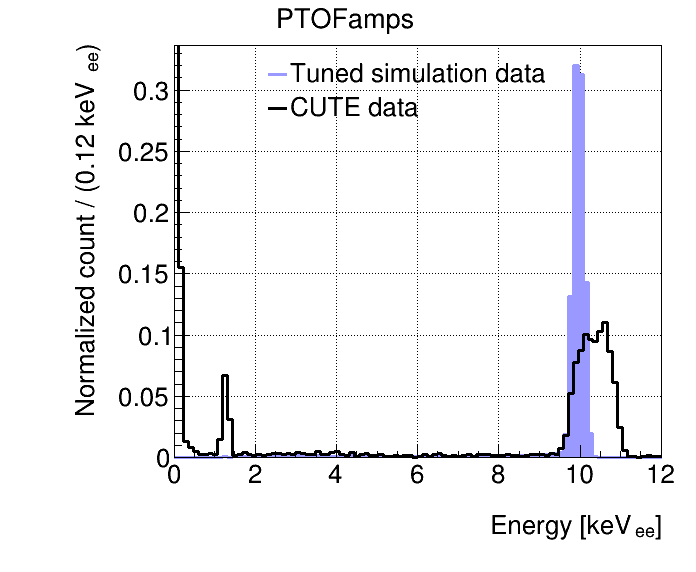

In [12]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", "PTOFamps;Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]" + ";Normalized count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data1 = RQdata['sim']['PTOFamps_keVee']

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-9)
h1.SetFillColor(ROOT.kBlue-9)
h1.SetFillStyle(1001)
#h1.SetMaximum(1000)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h2", ";Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]" + ";Normalized count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data2 = RQdata['data']['PTOFamps_keVee']

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kBlack)
    
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.38, 0.78, 0.53, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "Tuned simulation data", "l")
legend.AddEntry(h2, "CUTE data", "l")
legend.SetTextSize(0.05)

c.SetLeftMargin(0.25)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Scale(DMCscaling)
h2.Scale(CUTEscaling)
h1.Draw("HIST")
h2.Draw("HIST SAME")
legend.Draw()
c.SetGrid(1,1)
#c.SetLogy()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


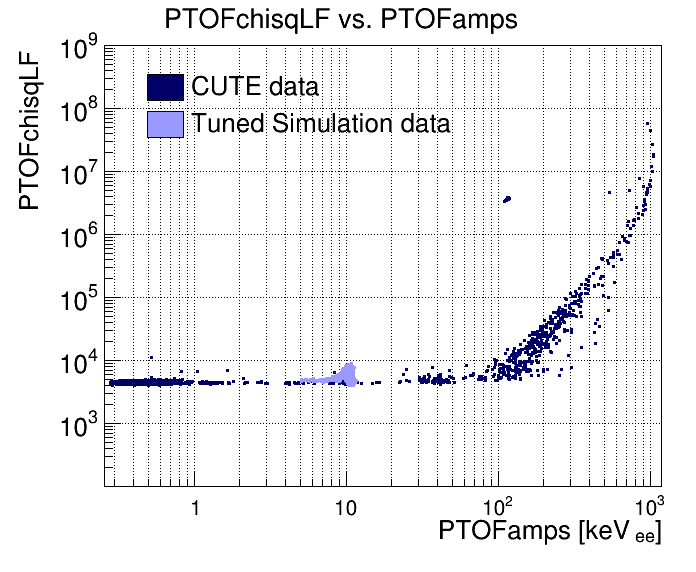

In [19]:
# Create canvas
c = ROOT.TCanvas("c", "Canvas", 700, 600)

g1 = ROOT.TGraph(len(RQdata['data']['PTOFamps_keVee']), RQdata['data']['PTOFamps_keVee'], RQdata['data']['PTOFchisqLF'])
g1.SetMarkerColor(ROOT.kBlue+3)
g1.SetFillColor(ROOT.kBlue+3)
g1.SetMarkerStyle(21)
g1.SetMarkerSize(0.4)
g1.GetXaxis().SetRangeUser(1e-1, 2e3)
g1.GetXaxis().SetLabelSize(0.04)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.SetMinimum(1e2)
g1.SetMaximum(1e9)
g1.SetTitle("PTOFchisqLF vs. PTOFamps;PTOFamps [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}];PTOFchisqLF")

# Second dataset
g2 = ROOT.TGraph(len(RQdata['sim']['PTOFamps_keVee']), RQdata['sim']['PTOFamps_keVee'], RQdata['sim']['PTOFchisqLF'])
g2.SetMarkerColor(ROOT.kBlue-9)
g2.SetFillColor(ROOT.kBlue-9)
g2.SetMarkerStyle(21)
g2.SetMarkerSize(0.4)
g2.GetXaxis().SetRangeUser(1e-1, 2e3)
g2.GetXaxis().SetLabelSize(0.04)
g2.GetYaxis().SetLabelSize(0.05)
g2.GetXaxis().SetTitleSize(0.05)
g2.GetYaxis().SetTitleSize(0.05)
g2.SetMinimum(1e2)
g2.SetMaximum(1e9)
g2.SetMarkerStyle(21)
g2.SetMarkerSize(0.4)

# Draw second graph on same canvas
g1.Draw("AP")  # P = points, SAME = overlay
g2.Draw("P SAME") 

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.2, 0.75, 0.5, 0.88)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(g1, "CUTE data", "f")
legend.AddEntry(g2, "Tuned Simulation data", "f")
legend.SetTextSize(0.05)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.Draw()
c.SetLogy()
c.SetLogx()
c.SetGrid(1,1)
legend.Draw()

In [21]:
K_DMC_cut = (RQdata['sim']['PTOFamps_keVee'] > 9) & (RQdata['sim']['PTOFamps_keVee'] < 12)
K_CUTE_cut = (RQdata['data']['PTOFamps_keVee'] > 9) & (RQdata['data']['PTOFamps_keVee'] < 12)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


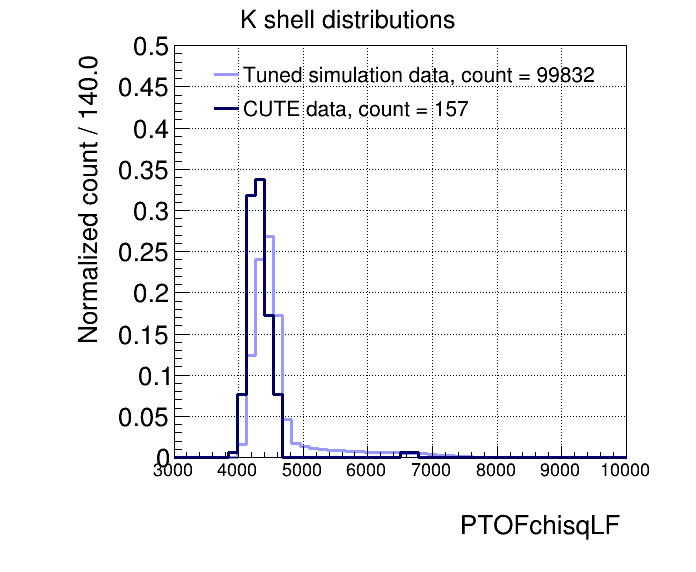

In [22]:
ROOT.gStyle.SetOptStat(0)
bins_start = 3000
bins_end = 10000
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", "K shell distributions;PTOFchisqLF" + ";Normalized count / " + str(bindiff) + "", nbins, bins_start, bins_end)
data1 = RQdata['sim']['PTOFchisqLF'][K_DMC_cut]

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-9)
#h1.SetFillColor(ROOT.kBlue-9)
h1.SetFillStyle(1001)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h2", ";PTOFchisqLF" + ";Count / " + str(bindiff) + "", nbins, bins_start, bins_end)
data2 = RQdata['data']['PTOFchisqLF'][K_CUTE_cut]

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kBlue+3)
#h2.SetFillColor(ROOT.kBlue+3)
h2.SetFillStyle(1001)
#h2.SetMaximum(1000)
    
h1.GetXaxis().SetLabelSize(0.035)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.3, 0.78, 0.5, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, f"Tuned simulation data, count = {len(data1)}", "l")
legend.AddEntry(h2, f"CUTE data, count = {len(data2)}", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.25)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.1)
c.SetTopMargin(0.08)
h1.Scale(1.0 / h1.Integral())
h1.SetMaximum(0.5)
h1.Draw("HIST")
h2.Scale(1.0 / h2.Integral())
h2.Draw("HIST SAME")
legend.Draw()
c.SetGrid(1,1)
c.Draw()

In [24]:
cut = K_DMC_cut & (RQdata['sim']['PTOFchisqLF'] > 5000)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


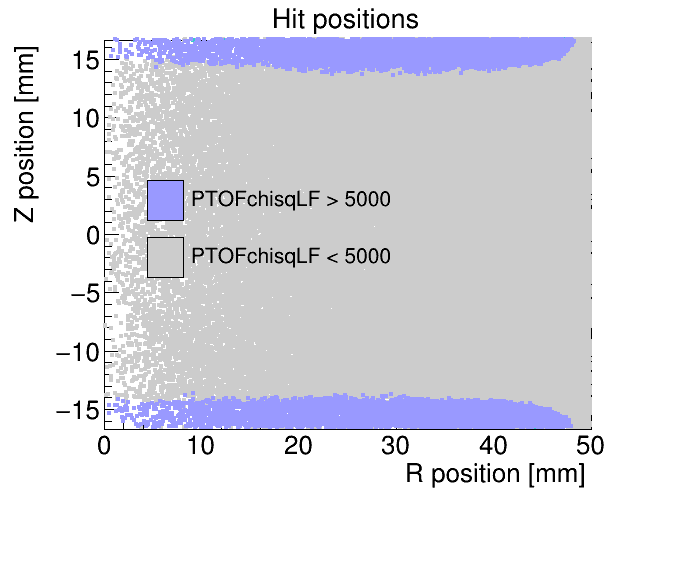

In [31]:
g1 = ROOT.TGraph(len(R[cut]), R[cut], Z[cut])
g1.SetMarkerStyle(21)
g1.SetMarkerSize(0.6)
g1.SetMarkerColor(ROOT.kBlue-9)
g1.SetFillColor(ROOT.kBlue-9)
g1.GetXaxis().SetRangeUser(0, 50)
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.SetMinimum(-33.33/2)
g1.SetMaximum(33.33/2)

g5 = ROOT.TGraph(len(R), R, Z)
g5.SetMarkerStyle(21)
g5.SetMarkerSize(0.6)
g5.SetMarkerColor(ROOT.kGray)
g5.SetFillColor(ROOT.kGray)
g5.GetXaxis().SetRangeUser(0, 50)
g5.GetXaxis().SetLabelSize(0.05)
g5.GetYaxis().SetLabelSize(0.05)
g5.GetXaxis().SetTitleSize(0.05)
g5.GetYaxis().SetTitleSize(0.05)
g5.SetMinimum(-33.33/2)
#g5.SetMinimum(16)
g5.SetMaximum(33.33/2)

# Create canvas
#c = ROOT.TCanvas("c", "Canvas", int(500*2), int(300*2))
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.25)
c.SetRightMargin(0.15)
c.SetTopMargin(0.07)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.2, 0.5, 0.5, 0.7)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(g1, f"PTOFchisqLF > 5000", "f")
legend.AddEntry(g5, f"PTOFchisqLF < 5000", "f")
legend.SetTextSize(0.04)

# Draw first graph
g5.SetTitle("Hit positions;R position [mm];Z position [mm]")
g5.Draw("AP")  # A = axis, P = points

# Draw second graph on same canvas
g4.Draw("P SAME")  # P = points, SAME = overlay
g3.Draw("P SAME")  # P = points, SAME = overlay
g2.Draw("P SAME")  # P = points, SAME = overlay
g1.Draw("P SAME")  # P = points, SAME = overlay
legend.Draw()

c.Draw()